# **animove**
### Spatial Dynamics, Temporal Rhythms, and Biological Influences on Bobcat (*Lynx rufus*) Movement Near Black Rock Forest, New York

**By**: Zhean Robby Ganituen, Jaztin Jacob Jimenez, Reece Benedict Orense, Ashley Paulianna Reyes, and Matthew Fraser Sim

---

# **1. Abstract**
This study investigates the spatial, temporal, and biological factors influencing the movement behaviors of Bobcats (*Lynx rufus*) near Black Rock Forest, New York. Utilizing high-frequency GPS telemetry data and biological metadata collected between 2020 and 2026, we explore individual activity budgets, circadian rhythms, and territorial boundaries. By applying spatial mapping techniques (KDE) and temporal feature engineering, this exploratory data analysis aims to uncover how intrinsic biological traits (such as sex, mass, and life-stage) correlate with the varied movement patterns of this elusive carnivore.

**Dataset**: LaPoint, S. 2026. Data from: Study “Carnivore movements near Black Rock Forest New York” [part]. Movebank Data Repository.

**Paper**: Oliver, R.Y. et al. 2026. Interacting effects of human presence and landscape modification on birds and mammals. Science. 392, 6800 (May 2026), 879–884. https://doi.org/10.1126/science.adq3396.

---

# **2. Dataset Description**
"Carnivore movements near Black Rock Forest New York" is a telemetry-based dataset sourced from the Movebank Data Repository. It is composed of a main logsheet monitoring the geographical coordinates and ambient environmental conditions of _Lynx rufus_ (Bobcat) and _Pekania pennanti_ (Fisher) across tracking deployments between the years 2020-2026 and a referential sheet containing individual specimen's biological information and eos-tag metadata. This sort of dataset is particularly useful for modeling fine-scale wildlife corridor usage, mapping home ranges, evaluating how habitat modification impacts mammalian movement, and uncovering how individual biological profiles—such as sex, mass, and age class—influence daily activity rhythms and territorial boundaries in changing ecosystems.

The raw, integrated dataset (`joined.csv`) was created by merging high-frequency GPS tracking data (the "pings") with the biographical capture metadata of the animals. Initially, the `main` dataset contains `131930` entries logging information across `26 variables` while the `reference` dataset contains `9` observations with information across `24 variables`.

### Data Collection Method
The data was collected in the field via live-trapping and collaring as part of the Hudson Highlands Wildlife Connectivity Project. Researchers captured the bobcats (*Lynx rufus*) using Camtrip cage traps disguised with debris and landscape cloth. While sedated, researchers monitored their vital signs, recorded their biological metrics (mass, sex, life-stage), and fitted them with "e-obs" brand GPS tracking collars (weighing 170g for males and 20g for females) before safely releasing them. These collars were programmed to automatically record the animal's exact spatial coordinates, speed, and ambient temperature, with data retrieved wirelessly via base stations.

### Implications of the Collection Method
This specific method of capture and automated telemetry introduces several critical implications and potential biases for our data insights:
1. **Sample Size vs. Observation Count:** While the automated collars generated a massive volume of observations (over 100,000 pings), the actual sample size of distinct individuals is extremely small ($n=7$ bobcats). Any behavioral trends discovered may not generalize to the entire *Lynx rufus* species but rather reflect the specific habits of this local population.
2. **Capture Bias:** The dataset only includes animals that were successfully lured into cage traps. It is highly probable that trap-shy individuals—which may inherently exhibit different behavioral, spatial, or territorial patterns—are entirely missing from this dataset. 
3. **Spatiotemporal Autocorrelation:** Because the data is collected continuously from the same individuals, the observations are not statistically independent. An animal's location at 2:00 PM is highly dependent on its location at 1:00 PM.
4. **Hardware Limitations:** The integrated instantaneous ground speed sensor relies on firmware inaccuracy estimations. Relying strictly on raw ground velocity vectors may inflate the perceived variance in behavioral patterns. Additionally, GPS signals can be blocked by dense canopy cover, topography, or weather, occasionally resulting in missed fixes or inaccurate coordinate estimations (`eobs:horizontal-accuracy-estimate`), which necessitated rigorous data cleaning prior to analysis.

## **Research Questions**

The goal of this project is to answer the general question:

> **How do spatial movement patterns, territorial boundaries, and activity levels vary among individual Bobcats (Lynx rufus) in the Black Rock Forest?**

To answer this general question, we have constructed the following research questions:

1. What is the distribution of the tracking data among the different bobcats, and what are their biological profiles?
2. How do general activity levels and ground speeds vary among individual bobcats?
3. Where are the territorial boundaries of these bobcats, and do their home ranges overlap?
4. Do all bobcats share the same daily temporal rhythm, or do individuals hunt or rest at different times?
   
Because our research question focuses strictly on an intra-species analysis of Bobcat behavior, we will be filtering the dataset to isolate the *Lynx rufus* records. Note that while there are 7 observed Bobcats, there is no observation given the `animal-id` of 7 for reasons outside the reach of the researchers conducting this study. There are no erroneous entries for an individual tagged as `LYRU_0007`, therefore this skipped or missing id number has no bearing on the dataset.

To answer our specific questions regarding territoriality, daily rhythms, and biological impacts, we will focus on the following key variables, which can be grouped into four distinct categories:

### Identifiers
* **`animal-id`**: The unique identifier assigned to a specific animal (e.g., `LYRU_0001`). This allows us to track individual behavior and group data points by specific bobcats.
* **`animal-taxon`**: The scientific name of the species (*Lynx rufus*). Used primarily to filter the initial dataset.

### Biological Attributes
* **`animal-sex`**: The biological sex of the bobcat (`m` for male, `f` for female).
* **`animal-life-stage`**: The developmental stage of the bobcat at the time of collar deployment (e.g., `adult`, `subadult`, `juvenile`).
* **`animal-mass`**: The weight of the bobcat when it was captured, recorded in grams. 

### Spatial and Movement Metrics
* **`location-long`** & **`location-lat`**: The exact geographical coordinates (longitude and latitude) of the animal at the time of the GPS recording. Crucial for mapping territorial boundaries and home ranges.
* **`ground-speed`**: The estimated speed the bobcat was moving at the time of the recording (in meters per second), serving as our primary proxy for "activity level."

### Temporal Metrics
* **`timestamp`**: The exact UTC date and time the GPS location was recorded. During our preprocessing phase, this will be transformed to extract local time zones (`timestamp-local`), specific hours of the day (`hour-local`), and seasonal data to analyze daily and yearly behavioral rhythms.

## **Definition of Terms**
To ensure clarity throughout our exploratory data analysis, we define the key ecological and data science terms used in this study below:

- **Home Range / Territorial Boundary**: The spatial area in which an individual bobcat lives, travels, and hunts. In this dataset, it is mapped using longitudinal and latitudinal GPS coordinates.
- **Kernel Density Estimation (KDE)**: A spatial data visualization technique used to create a continuous "heatmap" of an animal's location points. This allows us to smoothly identify dense core territories and visualize where different animals' ranges naturally overlap.
- **Activity Level / Budget**: The proportion of time an animal spends actively moving versus resting. In this study, we infer activity levels primarily through the `ground-speed` metric.
- **Biological Attributes**: The intrinsic physical or demographic characteristics of an individual animal—specifically its sex, mass (in grams), and life-stage (juvenile, subadult, adult)—which may influence its spatial and temporal behavior.
- **Diel / Temporal Rhythm**: The synchronized, daily behavioral schedule of an animal occurring over a 24-hour cycle (e.g., shifting between periods of active travel and resting).


## **Project Plan and Data Handling Strategy**
To effectively answer our general research question regarding Bobcat spatial and temporal dynamics, our plan for handling this dataset involves the following phases:

> **Phase 0: Environment Setup and Merging**
* **Objective:** Establish global directory streams and unify involved csv files.
* **Approach:** Initialize path configurations for raw (`/data/raw/`) and processed (`/data/processed/`) sheets. Since the primary logsheet identifier column `individual-local-identifier` matches the secondary attribute key `animal-id` from the reference manifest, `MAIN_DF` is structurally renamed and combined via an inner relational database join (`pd.merge`) into a consolidated dataset (`JOIN_DF`).

> **Phase 1: Preprocessing Pipeline (Clean and Compress)**
* **Objective:** Abstract the logic and necessary helper functions for data preprocessing and apply the necessary cleaning.
* **Approach:** 
1. **Target Filtering:** The initial dataset contains a severe class imbalance (~88% Bobcats and ~12% Fishers, with the Fisher data heavily skewed toward a single individual). To ensure statistical validity and prevent generalization errors in future modeling, our first step is to filter the dataset to strictly isolate the *Lynx rufus* (Bobcat) records.
2. **Data Cleaning (`janitor.py`):** We will utilize custom cleaning modules to sanitize the tracking data. This includes removing invalid GPS fixes (e.g., failed 3D satellite connections), dropping telemetry points recorded outside the official collar deployment dates, and filtering out any coordinates flagged as system or manual outliers.
3. **Feature Engineering (`transformer.py`):** Because our temporal analysis relies heavily on daily schedules, we will engineer new features from the raw data. We will convert the default UTC timestamps into the local timezone (America/New_York) and extract specific attributes such as the `hour-local` and `season`. 
4. **Dimensionality Reduction (`reducer.py`):** The raw dataset contains numerous columns dedicated strictly to the physical tracking hardware (e.g., e-obs battery voltages, transmission checksums, and sensor statuses). We will drop these irrelevant diagnostic columns to streamline the dataset, retaining only the spatial, temporal, and biological variables necessary for our Exploratory Data Analysis (EDA).

> **Phase 2: Exploratory Profile Analysis (Addressing RQ1)**
* **Objective:** Group the tracking data by animal and review their physical and biological traits.
* **Approach:** Aggregate the data by each bobcat's unique IDs. We will combine their tracking statistics with their biological information (sex, weight, and life stage) to create an overview of the population. This phase also checks for data consistency and notes anomalies, like the unassigned tracking code index `LYRU_0007`.

> **Phase 3: Speed and Activity Analysis (Addressing RQ2)**
* **Objective:** Examine speed profiles and categorize activity budgets across individual animals.
* **Approach:** Construct descriptive summary profiles (mean, median, standard deviation, and bounding ranges) for raw `ground-speed`. By setting speed thresholds, we will classify tracking points into "resting" or "moving" states. This lets us calculate active-versus-inactive ratios and see how a bobcat's physiological profile alter its mobility.

> **Phase 4: Mapping Home Ranges and Overlap (Addressing RQ3)**
* **Objective:** Model geographical spatial configurations and identify overlapping boundaries, if any.
* **Approach:** Convert the latitude and longitude coordinates into a simulated map projection. Using `<todo>`, we will draw boundary lines around each animal's tracking points. We will then analyze whether the bobcats have established territories or home ranges and if there are intersections between these.

> **Phase 5: Daily Activity Rhythms (Addressing RQ4)**
* **Objective:** Document daily behavior charts over regular 24-hour day-night cycles.
* **Approach:** TO DO

## **Generative AI Use Policy**
**Statement:** During the preparation of this work, the author(s) used [NAME TOOL/SERVICE] for the following purposes:

[enumerate a description of all uses of generative AI]

After using this tool/service, the author(s) reviewed and edited the content as needed and take(s) full responsibility for the content of the publication.

## **0 setup**

Let's first import the Python libraries needed for the project and define some filenames which will be used throughout the dataset.

In [36]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

# Directories
DIR_DATA = "../data/"
DIR_RAW_DATA = DIR_DATA + "raw/"
DIR_PROC_DATA = DIR_DATA + "processed/"

# Output Filenames
OUT_JOINED_DATASET = DIR_RAW_DATA + "joined.csv"
OUT_PPROC_DATASET = DIR_PROC_DATA + "preprocessed.csv"

# DataFrames global variables
MAIN_DF = ()
REF_DF = ()
JOIN_DF = ()
PPROC_DF = ()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### **0.1 dataset loading**

Now, let's load the two raw datasets as a pandas `DataFrame`.

In [37]:
MAIN_DF = pd.read_csv(DIR_RAW_DATA + "main.csv")
REF_DF = pd.read_csv(DIR_RAW_DATA + "reference.csv")

C:\Users\Jaztin\AppData\Local\Temp\ipykernel_20236\795800667.py:1: DtypeWarning: Columns (0: manually-marked-outlier) have mixed types. Specify dtype option on import or set low_memory=False.
  MAIN_DF = pd.read_csv(DIR_RAW_DATA + "main.csv")


### **0.2 joining**

Before doing any cleaning, let's first join the two. 

To get an idea of what the dataset looks like. Let's first print the columns and information from each dataframe. From this, we can come up with a methodology for joining the two.

In [38]:
print("\t========== Main DataFrame ========== ")
print(MAIN_DF.info())

	========== Main DataFrame ========== 
<class 'pandas.DataFrame'>
RangeIndex: 131930 entries, 0 to 131929
Data columns (total 26 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   event-id                           131930 non-null  int64  
 1   visible                            131930 non-null  bool   
 2   timestamp                          131930 non-null  str    
 3   location-long                      126483 non-null  float64
 4   location-lat                       126483 non-null  float64
 5   data-decoding-software             131930 non-null  int64  
 6   eobs:battery-voltage               131930 non-null  int64  
 7   eobs:fix-battery-voltage           131930 non-null  int64  
 8   eobs:horizontal-accuracy-estimate  126483 non-null  float64
 9   eobs:key-bin-checksum              131930 non-null  int64  
 10  eobs:speed-accuracy-estimate       126483 non-null  float64
 11  eobs:start-

In [39]:
print("\t========== Reference DataFrame ========== ")
print(REF_DF.info())

	========== Reference DataFrame ========== 
<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   tag-id                 9 non-null      int64  
 1   animal-id              9 non-null      str    
 2   animal-taxon           9 non-null      str    
 3   deploy-on-date         9 non-null      str    
 4   deploy-off-date        8 non-null      str    
 5   animal-life-stage      9 non-null      str    
 6   animal-mass            9 non-null      float64
 7   animal-offspring       1 non-null      str    
 8   animal-parents         2 non-null      str    
 9   animal-sex             9 non-null      str    
 10  animal-siblings        2 non-null      str    
 11  attachment-body-part   9 non-null      str    
 12  attachment-type        9 non-null      str    
 13  deploy-on-latitude     1 non-null      float64
 14  deploy-on-longitude    1 non-

From here, the column `individual-local-identifier` (`ili`) from `MAIN_DF` and `animal-id` from `REF_DF` seem to be related to each other. Let's verify this claim by checking that the set of possible values for each column is the same.

In [40]:
unique_ili_id = set(MAIN_DF["individual-local-identifier"].unique())
unique_animal_id = set(REF_DF["animal-id"].unique())

print("\t========== Is ili and animal-id a potential join key? ==========")
if unique_ili_id == unique_animal_id:
    print("YES")
    print(unique_ili_id)
else:
    print("NO")

	========== Is ili and animal-id a potential join key? ==========
YES
{'PEPE_0001', 'LYRU_0008', 'LYRU_0002', 'LYRU_0006', 'LYRU_0005', 'LYRU_0003', 'LYRU_0004', 'PEPE_0002', 'LYRU_0001'}


Now that we know that `ili` and `animal-id` is the join key. We will now join `MAIN_DF` and `REF_DF` to construct `JOIN_DF`. But let's first rename `ili` to `animal-id`. Then, we'll call `pd.merge` on the join key (which is now `animal-id`).

In [41]:
MAIN_DF = MAIN_DF.rename(columns={"individual-local-identifier": "animal-id"})
JOIN_DF = pd.merge(MAIN_DF, REF_DF, on="animal-id")

Now let's see the columns and information of the dataset after performing the join. Let's ensure that information of the two datasets were kept after merging by performing some tests.

In [42]:
print("\t========== Joined DataFrame ========== ")
print("(Running tests...)")
print(
    "=== The total number of columns must be len(MAIN_DF.columns) + len(REF_DF.columns) - 1"
)
assert len(MAIN_DF.columns) + len(REF_DF.columns) - 1 == len(JOIN_DF.columns)

print("=== The total number of entries must be the max(len(MAIN_DF), len(REF_DF))")
assert max(len(MAIN_DF), len(REF_DF)) == len(JOIN_DF)

print()
print("(Saving joined dataset...)")
JOIN_DF.to_csv(OUT_JOINED_DATASET, index=False)

print()
print("=== JOIN_DF info")
print(JOIN_DF.info())

	========== Joined DataFrame ========== 
(Running tests...)
=== The total number of columns must be len(MAIN_DF.columns) + len(REF_DF.columns) - 1
=== The total number of entries must be the max(len(MAIN_DF), len(REF_DF))

(Saving joined dataset...)

=== JOIN_DF info
<class 'pandas.DataFrame'>
RangeIndex: 131930 entries, 0 to 131929
Data columns (total 49 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   event-id                           131930 non-null  int64  
 1   visible                            131930 non-null  bool   
 2   timestamp                          131930 non-null  str    
 3   location-long                      126483 non-null  float64
 4   location-lat                       126483 non-null  float64
 5   data-decoding-software             131930 non-null  int64  
 6   eobs:battery-voltage               131930 non-null  int64  
 7   eobs:fix-battery-voltage           131930 

## **# 3. Dataset Preprocessing**

Now that we have the joined dataset, we can proceed with the cleaning phase.


Three source files are important for this section:
- `janitor` defines functions and a shared interface for **cleaning**.
- `transformer` defines functions and a shared interface for **transforming** data into more useful formats.
- `reducer` defines variables and functions for **dimensionality reduction** (removing unnecessary columns).

In [43]:
from src import janitor, transformer, reducer

preprocess_step_df = JOIN_DF

### 3.1 Filtering Target Species (*Lynx rufus*)
Upon initial inspection, the dataset contains two species: *Lynx rufus* (Bobcats, ~88% of data) and *Pekania pennanti* (Fishers, ~12% of data). Furthermore, the Fisher data is heavily skewed toward a single individual. To prevent severe class imbalance and lack of generalization in future modeling (MCO2), we filter the dataset to strictly isolate the Bobcat records.

In [44]:
# Filter dataset to only include Bobcats (Lynx rufus)
from src.janitor import clean_runner, keep_only_bobcats

preprocess_step_df, report = clean_runner(preprocess_step_df, keep_only_bobcats)
report.out()

	========== Janitor ========== 
		Rows before		: 131930
		Rows remaining		: 116256
		Rows removed		: 15674
		Examples (max 3)	:                                                                                    0                                                  1                                                  2
event-id                                                                 14056446637                                        14056446638                                        14056446639
visible                                                                         True                                               True                                               True
timestamp                                                    2020-02-12 16:02:53.000                            2020-02-12 16:02:54.000                            2020-02-12 16:02:55.000
location-long                                                             -74.059272                                        

<p style="color: red;">ADD EXPLANATION.</p>

In [45]:
preprocess_step_df, report = janitor.clean_runner(
    df=preprocess_step_df, func=janitor.rem_fishers
)
report.out()

AttributeError: module 'src.janitor' has no attribute 'rem_fishers'

<p style="color: red;">ADD EXPLANATION.</p>

In [ ]:
preprocess_step_df, report = janitor.clean_runner(
    df=preprocess_step_df, func=janitor.rem_bad_gps
)
report.out()

AttributeError: module 'src.janitor' has no attribute 'rem_bad_gps'

<p style="color: red;">ADD EXPLANATION.</p>

In [ ]:
preprocess_step_df, report = janitor.clean_runner(
    df=preprocess_step_df, func=janitor.rem_with_markers
)
report.out()

	========== Janitor ========== 
		Rows before		: 116256
		Rows remaining		: 116251
		Rows removed		: 5
		Examples (max 3)	:                                                                                    0                                                  1                                                  2
event-id                                                                 14056446637                                        14056446638                                        14056446639
visible                                                                         True                                               True                                               True
timestamp                                                    2020-02-12 16:02:53.000                            2020-02-12 16:02:54.000                            2020-02-12 16:02:55.000
location-long                                                             -74.059272                                         -74

<p style="color: red;">ADD EXPLANATION.</p>

In [ ]:
preprocess_step_df, report = janitor.clean_runner(
    df=preprocess_step_df, func=janitor.rem_bad_fix
)
report.out()

	========== Janitor ========== 
		Rows before		: 116256
		Rows remaining		: 112237
		Rows removed		: 4019
		Examples (max 3)	:                                                                                    0                                                  1                                                  2
event-id                                                                 14056446637                                        14056446638                                        14056446639
visible                                                                         True                                               True                                               True
timestamp                                                    2020-02-12 16:02:53.000                            2020-02-12 16:02:54.000                            2020-02-12 16:02:55.000
location-long                                                             -74.059272                                         

### 3.3 Standard Data Cleaning: Missing Values and Duplicates
Standard machine learning practices require the removal of duplicate records and missing values (NaNs). Because our exploratory data analysis relies heavily on mapping territories and calculating activity budgets, any rows missing critical spatial coordinates (`location-lat`, `location-long`) or movement data (`ground-speed`) will cause graphing errors and model failures. We drop these invalid rows here.

In [ ]:
# Drop duplicates and rows missing critical spatial/speed data
from src.janitor import drop_dupes_and_nulls

preprocess_step_df, report = clean_runner(preprocess_step_df, drop_dupes_and_nulls)
report.out()

	========== Janitor ========== 
		Rows before		: 112237
		Rows remaining		: 112237
		Rows removed		: 0
		Examples (max 3)	:                                                                                    0                                                  1                                                  2
event-id                                                                 14056446637                                        14056446638                                        14056446639
visible                                                                         True                                               True                                               True
timestamp                                                    2020-02-12 16:02:53.000                            2020-02-12 16:02:54.000                            2020-02-12 16:02:55.000
location-long                                                             -74.059272                                         -74

<p style="color: red;">ADD EXPLANATION.</p>

In [ ]:
preprocess_step_df, report = transformer.transform_runner(
    df=preprocess_step_df, func=transformer.add_utc_time, source_cols=["timestamp"]
)
report.out()

	========== Transformer ========== 
		Added columns	: ['timestamp-utc']
		Before (max 3)	:
                                 0                        1                        2
event-id               14056446637              14056446638              14056446639
timestamp  2020-02-12 16:02:53.000  2020-02-12 16:02:54.000  2020-02-12 16:02:55.000
		After  (max 3)	:
                                       0                          1                          2
event-id                     14056446637                14056446638                14056446639
timestamp        2020-02-12 16:02:53.000    2020-02-12 16:02:54.000    2020-02-12 16:02:55.000
timestamp-utc  2020-02-12 16:02:53+00:00  2020-02-12 16:02:54+00:00  2020-02-12 16:02:55+00:00


<p style="color: red;">ADD EXPLANATION.</p>

In [ ]:
preprocess_step_df, report = janitor.clean_runner(
    df=preprocess_step_df, func=janitor.rem_outside_deploy
)
report.out()

	========== Janitor ========== 
		Rows before		: 112237
		Rows remaining		: 108803
		Rows removed		: 3434
		Examples (max 3)	:                                                                                    0                                                  1                                                  2
event-id                                                                 14056446637                                        14056446638                                        14056446639
visible                                                                         True                                               True                                               True
timestamp                                                    2020-02-12 16:02:53.000                            2020-02-12 16:02:54.000                            2020-02-12 16:02:55.000
location-long                                                             -74.059272                                         

<p style="color: red;">ADD EXPLANATION.</p>

In [ ]:
preprocess_step_df, report = janitor.clean_runner(
    df=preprocess_step_df, func=janitor.rem_dup_sessions
)
report.out()

AttributeError: module 'src.janitor' has no attribute 'rem_dup_sessions'

<p style="color: red;">ADD EXPLANATION.</p>

In [ ]:
preprocess_step_df, report = transformer.transform_runner(
    df=preprocess_step_df,
    func=transformer.add_local_features,
    source_cols=["timestamp-utc"],
)

report.out()

	========== Transformer ========== 
		Added columns	: ['timestamp-local', 'hour-local', 'date-local', 'month-local', 'season']
		Before (max 3)	:
                                       0                          1                          2
event-id                     14056446637                14056446638                14056446639
timestamp-utc  2020-02-12 16:02:53+00:00  2020-02-12 16:02:54+00:00  2020-02-12 16:02:55+00:00
		After  (max 3)	:
                                         0                          1                          2
event-id                       14056446637                14056446638                14056446639
timestamp-utc    2020-02-12 16:02:53+00:00  2020-02-12 16:02:54+00:00  2020-02-12 16:02:55+00:00
timestamp-local  2020-02-12 11:02:53-05:00  2020-02-12 11:02:54-05:00  2020-02-12 11:02:55-05:00
hour-local                              11                         11                         11
date-local                      2020-02-12                 2020-0

<p style="color: red;">ADD EXPLANATION.</p>

In [ ]:
preprocess_step_df, report = transformer.transform_runner(
    df=preprocess_step_df,
    func=transformer.add_movement,
    source_cols=["timestamp-utc", "location-lat", "location-long", "ground-speed"],
)

report.out()

	========== Transformer ========== 
		Added columns	: ['dt-seconds', 'step-meters', 'derived-speed-ms']
		Before (max 3)	:
                                       0                          1                          2
event-id                     14056446637                14056446638                14056446639
timestamp-utc  2020-02-12 16:02:53+00:00  2020-02-12 16:02:54+00:00  2020-02-12 16:02:55+00:00
location-lat                   41.380702                  41.380705                  41.380708
location-long                 -74.059272                 -74.059259                 -74.059251
ground-speed                        0.06                       0.09                       0.09
		After  (max 3)	:
                                          0                          1                          2
event-id                        14056446637                14056446638                14056446639
timestamp-utc     2020-02-12 16:02:53+00:00  2020-02-12 16:02:54+00:00  2020-02-12 16:02:55+

### 3.6 Dimensionality Reduction
The raw dataset contains numerous columns dedicated to tracking hardware diagnostics (e.g., e-obs battery voltages, sensor statuses). To streamline our dataset for analysis, we use our `reducer.py` module to drop these irrelevant columns. We ensure that we retain our engineered temporal features (`hour-local`, `season`), our spatial features (`location-long`, `location-lat`), and critically, our biological attributes (`animal-sex`, `animal-mass`, `animal-life-stage`) to answer our EDA questions.

In [ ]:
from src.reducer import reduce

# Updated columns to retain spatial, temporal, and biological data
COLS_TO_KEEP = [
    'animal-id',
    'timestamp-local',
    'hour-local',
    'season',
    'location-long',
    'location-lat',
    'ground-speed',
    'animal-sex',         
    'animal-mass',        
    'animal-life-stage'   
]

preprocess_step_df = reduce(preprocess_step_df, COLS_TO_KEEP)

print(f"Columns remaining: {len(preprocess_step_df.columns)}")
print(preprocess_step_df.head())

Columns remaining: 10
   animal-id           timestamp-local  hour-local  season  location-long  location-lat  ground-speed animal-sex  animal-mass animal-life-stage
0  LYRU_0001 2020-02-12 11:02:53-05:00          11  winter     -74.059272     41.380702          0.06          f       6300.0             adult
1  LYRU_0001 2020-02-12 11:02:54-05:00          11  winter     -74.059259     41.380705          0.09          f       6300.0             adult
2  LYRU_0001 2020-02-12 11:02:55-05:00          11  winter     -74.059251     41.380708          0.09          f       6300.0             adult
3  LYRU_0001 2020-02-12 12:00:25-05:00          12  winter     -74.059182     41.380840          0.09          f       6300.0             adult
4  LYRU_0001 2020-02-12 12:00:26-05:00          12  winter     -74.059185     41.380841          0.03          f       6300.0             adult


In [ ]:
preprocess_step_df = reducer.reduce(df=preprocess_step_df, cols=keep_cols)

assert len(preprocess_step_df.columns) == len(keep_cols)

NameError: name 'keep_cols' is not defined

Now that we have performed all cleaning steps, let's store the final result in `PPROC_DF` and check its information.

In [ ]:
PPROC_DF = preprocess_step_df

print("\t========== Preprocessed DataFrame ========== ")
print(PPROC_DF.info())

PPROC_DF.to_csv(OUT_PPROC_DATASET)

	========== Preprocessed DataFrame ========== 
<class 'pandas.DataFrame'>
RangeIndex: 108803 entries, 0 to 108802
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype                           
---  ------             --------------   -----                           
 0   animal-id          108803 non-null  str                             
 1   timestamp-local    108803 non-null  datetime64[us, America/New_York]
 2   hour-local         108803 non-null  int32                           
 3   season             108803 non-null  str                             
 4   location-long      108803 non-null  float64                         
 5   location-lat       108803 non-null  float64                         
 6   ground-speed       108803 non-null  float64                         
 7   animal-sex         108803 non-null  str                             
 8   animal-mass        108803 non-null  float64                         
 9   animal-life-stage  108803 non-null

## **2 Exploratory Data Analysis**

## **Setup and data overview**

The preprocessed dataset is already in memory as `PPROC_DF`. Here we import the plotting libraries, set one visual theme for every figure below, and take a quick look at how much data each bobcat contributes before we start plotting.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")

# Plot off a copy so nothing here changes the preprocessed frame.
EDA_DF = PPROC_DF.copy()

Before plotting anything, it helps to see what we are working with. The table below shows how many fixes each bobcat contributed, which seasons it was tracked through, and how often the collar took a reading. Those numbers decide how much the pooled averages can really be trusted.

In [ ]:
# How much each bobcat contributes, how many seasons it covers, and its date span.
overview = (
    EDA_DF.groupby("animal-id")
    .agg(
        n_fixes=("event-id", "size"),
        seasons=("season", "nunique"),
        first_day=("date-local", "min"),
        last_day=("date-local", "max"),
    )
    .sort_values("n_fixes", ascending=False)
)
overview["share_%"] = (100 * overview["n_fixes"] / len(EDA_DF)).round(1)
print(overview)

# How often the collar recorded a fix (seconds between consecutive fixes).
print("\nSampling interval, dt-seconds:")
print(EDA_DF["dt-seconds"].describe(percentiles=[0.25, 0.5, 0.75, 0.95]).round(0))

KeyError: "Label(s) ['date-local', 'event-id'] do not exist"

The sample is lopsided. `LYRU_0002` and `LYRU_0003` alone account for about 78% of the fixes, so a pooled average is mostly describing those two cats. At the other end, `LYRU_0005` and `LYRU_0006` have only a few hundred fixes each from a single season, so their individual numbers are noisy and easy to over-read. Five of the seven cats (`LYRU_0001` through `LYRU_0004` and `LYRU_0008`) were tracked across at least two seasons, which is what Question #3 relies on, and only `LYRU_0001` covers all four.

The collar took a reading about every 2 minutes (the median `dt-seconds` is 120), and that spacing holds up across the whole day, so it is fair to compare movement from one hour to the next. Some gaps do stretch to an hour or more. Those make the occasional step look longer than it should, but they are not concentrated at any particular time of day, so they mostly add noise rather than bias.

### **Question #1: What is the distribution of the tracking data among the different bobcats, and what are their biological profiles?**

We begin with creating a biological profile for each bobcat within the dataset. The biologoical profile consists of their sex, mass, lifestage, and their number of locations that were tracked. The number of tracked locations of each bobcat will be used to display the distribution of bobcat.

	========== BIOLOGICAL PROFILES & DATA DISTRIBUTION ========== 
           total_loc sex    mass life_stage  dataset_distribution_%
animal-id                                                          
LYRU_0002      40614   f  7200.0   subadult                    37.3
LYRU_0003      33223   f  5000.0   juvenile                    30.5
LYRU_0001      26721   f  6300.0      adult                    24.6
LYRU_0004       7416   m  8000.0   juvenile                     6.8
LYRU_0006        467   m  6700.0   subadult                     0.4
LYRU_0005        362   f  5400.0   juvenile                     0.3


C:\Users\Jaztin\AppData\Local\Temp\ipykernel_20236\2930239498.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


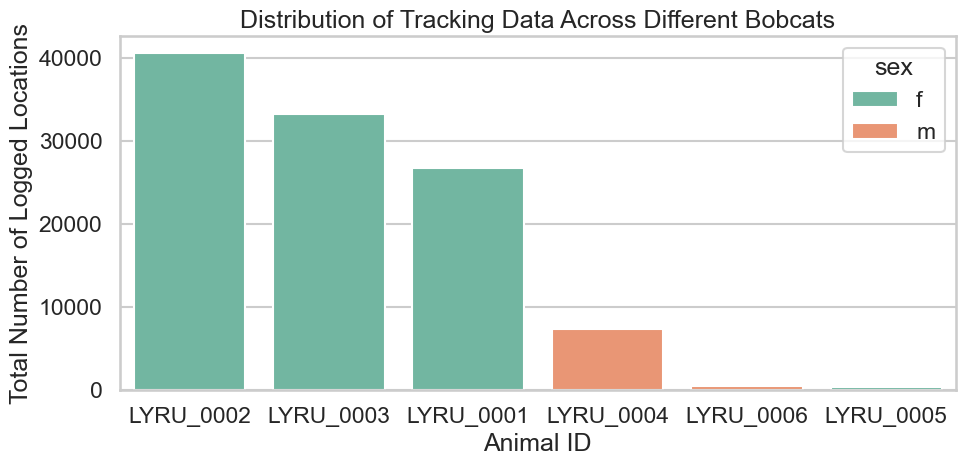

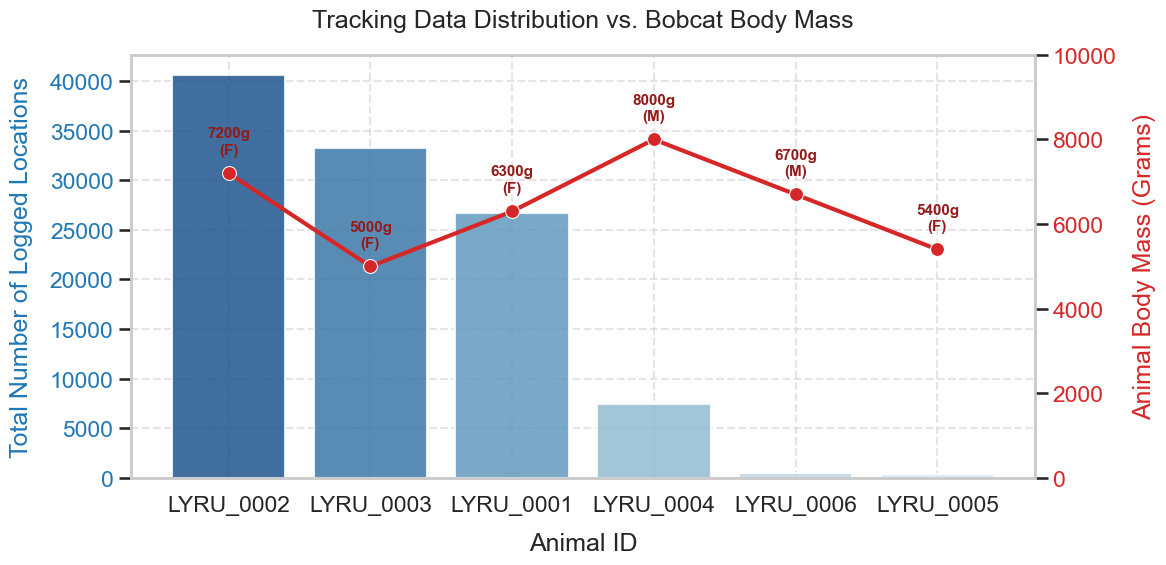

In [67]:
print("\t========== BIOLOGICAL PROFILES & DATA DISTRIBUTION ========== ")
# make biological profile of each bobcat
bio_prof = EDA_DF.groupby("animal-id").agg(
    total_loc=('location-lat', 'count'),
    sex=('animal-sex', 'first'),
    mass=('animal-mass', 'first'),
    life_stage=('animal-life-stage', 'first')
).sort_values('total_loc', ascending=False)

bio_prof['dataset_distribution_%'] = (bio_prof['total_loc'] / len(EDA_DF) * 100).round(1)

print(bio_prof)

# display the distribution of bobcat mass through a bar chart
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    data=bio_prof.reset_index(), 
    x='animal-id', 
    y='total_loc', 
    hue='sex',          
    palette='Set2',
    ax=ax
)

ax.set_title("Distribution of Tracking Data Across Different Bobcats")
ax.set_xlabel("Animal ID")
ax.set_ylabel("Total Number of Logged Locations")
plt.tight_layout()

# okay now lets try to plot through biplot
fig, ax1 = plt.subplots(figsize=(12, 6))

# Draw bars to represent the scale of fixes contributed by each cat
sns.barplot(
    data=bio_prof,
    x='animal-id',
    y='total_loc',
    palette='Blues_r',  # Clean gradient showing high to low data volume
    ax=ax1,
    alpha=0.85
)

ax1.set_title("Tracking Data Distribution vs. Bobcat Body Mass", pad=20)
ax1.set_xlabel("Animal ID", labelpad=12)
ax1.set_ylabel("Total Number of Logged Locations", color='#1f77b4', labelpad=12)
ax1.tick_params(axis='y', labelcolor='#1f77b4')
ax1.grid(True, linestyle='--', alpha=0.5)

# Create a twin axis that shares the exact same X-axis positions
ax2 = ax1.twinx()

# Overlay a line with pronounced circular markers to trace weight shifts
sns.lineplot(
    data=bio_prof,
    x='animal-id',
    y='mass',
    color='#d62728',    
    marker='o',
    markersize=10,
    linewidth=3,
    ax=ax2,
    sort=False           #
)

ax2.set_ylabel("Animal Body Mass (Grams)", color='#d62728', labelpad=12)
ax2.tick_params(axis='y', labelcolor='#d62728')
ax2.grid(False)

# Add clear data labels above the line markers to show exact masses
for idx, row in bio_prof.iterrows():
    ax2.annotate(
        f"{int(row['mass'])}g\n({row['sex'].upper()})",
        xy=(idx, row['mass']),
        xytext=(0, 12),
        textcoords='offset points',
        ha='center',
        va='bottom',
        fontsize=11,
        color='#941a1a',
        weight='bold'
    )

# Adjust the vertical window so the annotations aren't cut off by the frame boundary
ax2.set_ylim(0, bio_prof['mass'].max() * 1.25)

plt.tight_layout()

<p style="color: red;">ADD EXPLANATION.</p>

### **Question #2: How do general activity levels and ground speeds vary among individual bobcats?**

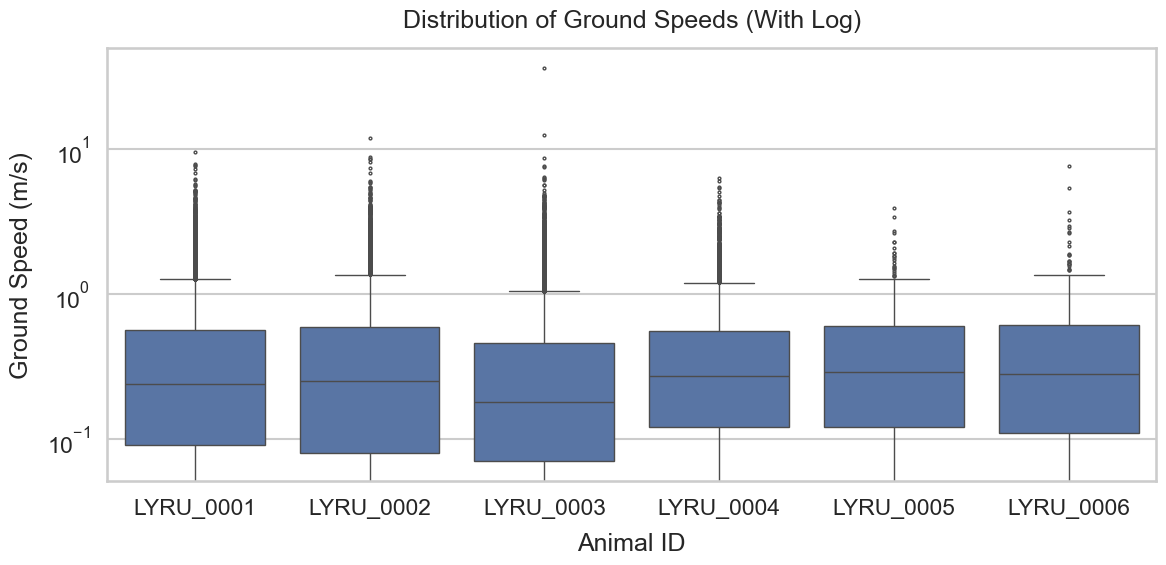

In [68]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.boxplot(
    data=EDA_DF,
    x='animal-id',
    y='ground-speed',
    ax=ax,
    fliersize=2
)

# This line activates the logarithmic scaling
ax.set_yscale('log')

ax.set_title("Distribution of Ground Speeds (With Log)", pad=15)
ax.set_xlabel("Animal ID", labelpad=10)
ax.set_ylabel("Ground Speed (m/s)", labelpad=10)

plt.tight_layout()

<p style="color: red;">ADD EXPLANATION.</p>

### **Question #3: Where are the territorial boundaries of these bobcats, and do their home ranges overlap?**


<p style="color: red;">ADD EXPLANATION.</p>

### **Question #4: Do all bobcats share the same daily temporal rhythm, or do individuals hunt or rest at different times?**

<p style="color: red;">ADD EXPLANATION.</p>